In [9]:
# === Colab 호환 셋업 (자동 추가) ===
import torch as _t
_t._orig_load = getattr(_t, '_orig_load', _t.load)
def _compat_load(*a, **k):
    k.setdefault('weights_only', False)
    return _t._orig_load(*a, **k)
_t.load = _compat_load
try:
    import matplotlib; matplotlib.rcParams['axes.unicode_minus'] = False
except Exception: pass
print('[colab-compat] torch.load weights_only=False 패치 적용')

[colab-compat] torch.load weights_only=False 패치 적용


In [10]:
import os
os.makedirs(os.path.expanduser('~/aiffel/object_detection/data'), exist_ok=True)

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as NF                     # nn.functional (relu, one_hot, bce ...)
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF       # 이미지 변환용 (resize, pad, hflip ...)
import torchvision.models as models
from torchvision.models import ResNet50_Weights
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader, Dataset, random_split, Subset

import os, copy
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

DATA_PATH = '/content/object_detection/data'   # KITTI가 <DATA_PATH>/Kitti/raw/ 아래로 받아집니다.
os.makedirs(DATA_PATH, exist_ok=True)

In [12]:
# torchvision이 제공하는 KITTI(2D object detection) 데이터셋을 내려받습니다.
kitti_train = torchvision.datasets.Kitti(root=DATA_PATH, train=True, download=True)
kitti_test  = torchvision.datasets.Kitti(root=DATA_PATH, train=False, download=True)

# KITTI의 8개 클래스(과거 tfds 버전과 동일, 'DontCare'는 제외)
KITTI_CLASSES = ['Car', 'Van', 'Truck', 'Pedestrian',
                 'Person_sitting', 'Cyclist', 'Tram', 'Misc']
NAME_TO_ID = {name: i for i, name in enumerate(KITTI_CLASSES)}

def parse_kitti_target(target):
    """torchvision KITTI 타깃(list of dict) -> (boxes[xyxy px], class_ids)."""
    boxes, cls_ids = [], []
    for obj in (target or []):
        name = obj['type']
        if name not in NAME_TO_ID:          # 'DontCare' 등은 건너뜀
            continue
        boxes.append(obj['bbox'])           # [x_min, y_min, x_max, y_max] (픽셀)
        cls_ids.append(NAME_TO_ID[name])
    boxes = torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4)
    cls_ids = torch.tensor(cls_ids, dtype=torch.int64)
    return boxes, cls_ids

100%|██████████| 12.6G/12.6G [09:23<00:00, 22.3MB/s]
100%|██████████| 5.60M/5.60M [00:01<00:00, 4.76MB/s]


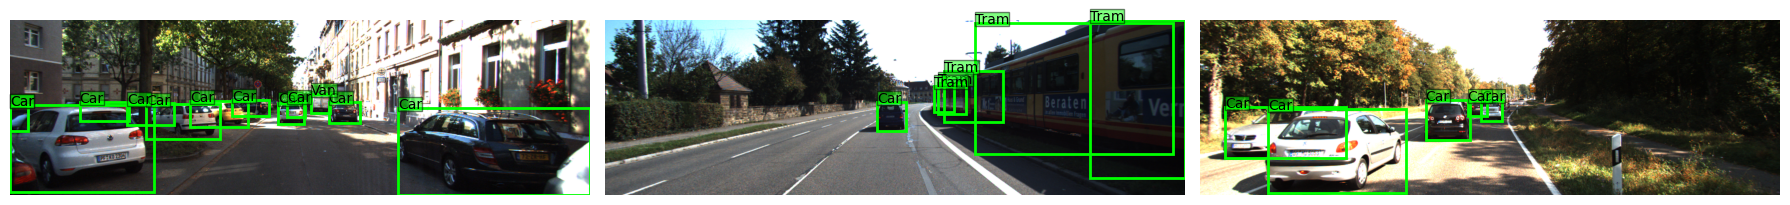

In [13]:
# tfds.show_examples 대신, 학습 데이터 몇 장을 바운딩 박스와 함께 직접 그려보기
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, idx in zip(axes, range(3)):
    image, target = kitti_train[idx]
    ax.imshow(image)
    for obj in target:
        if obj['type'] not in NAME_TO_ID:
            continue
        x1, y1, x2, y2 = obj['bbox']
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                   fill=False, edgecolor='lime', linewidth=2))
        ax.text(x1, y1, obj['type'], color='black',
                bbox={'facecolor': 'lime', 'alpha': 0.5, 'pad': 0})
    ax.axis('off')
plt.tight_layout()
plt.show()

In [14]:
# 데이터셋 정보 확인 (tfds의 ds_info 대체)
print(f"train 이미지 수: {len(kitti_train)}")
print(f"test  이미지 수: {len(kitti_test)}")
print(f"클래스({len(KITTI_CLASSES)}개): {KITTI_CLASSES}")

train 이미지 수: 7481
test  이미지 수: 7518
클래스(8개): ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc']


------ target(첫 번째 객체) ------
{'type': 'Car', 'truncated': 0.0, 'occluded': 0, 'alpha': -1.54, 'bbox': [572.99, 176.63, 629.55, 222.6], 'dimensions': [1.36, 1.69, 3.38], 'location': [-0.27, 1.5, 23.37], 'rotation_y': -1.55}
------ 파싱 결과 ------
boxes(xyxy, px): torch.Size([12, 4])
class_ids     : [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]


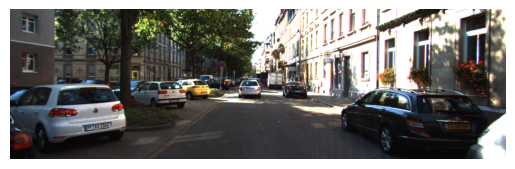

In [15]:
# kitti_train[0] 으로 (이미지, 타깃) 하나를 뽑아 직접 확인
image, target = kitti_train[0]

print('------ target(첫 번째 객체) ------')
print(target[0])

boxes, cls_ids = parse_kitti_target(target)
print('------ 파싱 결과 ------')
print('boxes(xyxy, px):', boxes.shape)
print('class_ids     :', cls_ids.tolist())

plt.imshow(image)
plt.axis('off')
plt.show()

```
데이터셋 이해를 위한 예시
Values    Name      Description
----------------------------------------------------------------------------
   1    type         Describes the type of object: 'Car', 'Van', 'Truck',
                     'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram',
                     'Misc' or 'DontCare'
   1    truncated    Float from 0 (non-truncated) to 1 (truncated), where
                     truncated refers to the object leaving image boundaries
   1    occluded     Integer (0,1,2,3) indicating occlusion state:
                     0 = fully visible, 1 = partly occluded
                     2 = largely occluded, 3 = unknown
   1    alpha        Observation angle of object, ranging [-pi..pi]
   4    bbox         2D bounding box of object in the image (0-based index):
                     contains left, top, right, bottom pixel coordinates
   3    dimensions   3D object dimensions: height, width, length (in meters)
   3    location     3D object location x,y,z in camera coordinates (in meters)
   1    rotation_y   Rotation ry around Y-axis in camera coordinates [-pi..pi]
   1    score        Only for results: Float, indicating confidence in
                     detection, needed for p/r curves, higher is better.
```

# 데이터 파이프 라인
---
먼저 주어진 KITTI 데이터를 학습에 맞는 형태로 바꾸어 주어야 합니다. 이때 사용할 데이터 파이프라인을 구축합니다.

데이터 파이프라인은 총 4단계로 이루어집니다.

  1. x와 y좌표 위치 교체
  2. 무작위로 수평 뒤집기(Flip)
  3. 이미지 크기 조정 및 패딩 추가
  4. 좌표계를 [x_min, y_min, x_max, y_max]에서 [cx, cy, width, height]으로 수정

독립적인 함수를 각각 작성합니다.

In [16]:
# torchvision KITTI는 bbox를 (x_min, y_min, x_max, y_max) 픽셀 좌표로 제공하므로
# (과거 tfds 버전에서 필요했던) 좌표 축 교환은 전처리 단계에서 필요하지 않습니다.
# 참고용으로 축을 바꾸는 유틸 함수만 남겨둡니다.
def swap_xy(boxes):
    return torch.stack([boxes[:, 1], boxes[:, 0], boxes[:, 3], boxes[:, 2]], dim=-1)

In [17]:
def random_flip_horizontal(image, boxes):
    # image: [C, H, W] 텐서, boxes: [N, 4] (x_min, y_min, x_max, y_max) 픽셀
    if torch.rand(1).item() > 0.5:
        _, _, width = image.shape
        image = TF.hflip(image)
        boxes = torch.stack(
            [width - boxes[:, 2], boxes[:, 1], width - boxes[:, 0], boxes[:, 3]], dim=-1
        )
    return image, boxes

가로, 세로 비율을 유지하면서 크기 조절하고 stride의 배수가 되도록 padding

In [18]:
def resize_and_pad_image(image, training=True):
    min_side = 800.0
    max_side = 1333.0
    min_side_range = [640, 1024]
    stride = 128.0

    image_shape = torch.tensor(image.shape[-2:], dtype=torch.float32)  # [H, W]
    if training:
        min_side = torch.empty(1).uniform_(min_side_range[0], min_side_range[1]).item()
    ratio = min_side / torch.min(image_shape)
    if ratio * torch.max(image_shape) > max_side:
        ratio = max_side / torch.max(image_shape)
    new_shape = ratio * image_shape
    new_size = [int(new_shape[0].round().item()), int(new_shape[1].round().item())]  # [H', W']
    image = TF.resize(image, new_size)

    padded = (torch.ceil(new_shape / stride) * stride).int().tolist()
    pad_h = padded[0] - new_size[0]
    pad_w = padded[1] - new_size[1]
    image = TF.pad(image, [0, 0, pad_w, pad_h])  # (left, top, right, bottom)
    return image, torch.tensor(new_size, dtype=torch.float32), float(ratio)

In [19]:
def convert_to_xywh(boxes):
    return torch.cat(
        [(boxes[..., :2] + boxes[..., 2:]) / 2.0,
         boxes[..., 2:] - boxes[..., :2]],
        dim=-1
    )

In [20]:
def preprocess_data(image, boxes, class_ids, training=True):
    # image: [C, H, W] 텐서(0~1), boxes: [N, 4] (x_min, y_min, x_max, y_max) 픽셀
    if training:
        image, boxes = random_flip_horizontal(image, boxes)
    image, _, ratio = resize_and_pad_image(image, training=training)

    boxes = boxes * ratio                 # 이미지 리사이즈 비율만큼 박스도 함께 스케일
    boxes = convert_to_xywh(boxes)        # (x_min,y_min,x_max,y_max) -> (cx, cy, w, h)
    return image, boxes, class_ids

# 인코딩
---
One stage detector에서는 Anchor Box라는 정해져 있는 위치, 크기, 비율 중에 하나로 물체의 위치가 결정됩니다.

또, RetinaNet에서는 FPN을 사용하기 때문에 Anchor Box가 더 많이 필요합니다. FPN의 각 층마다 Anchor Box가 필요하기 때문입니다. RetinaNet의 FPN에서 pyramid level은 개수가 미리 약속되어 있기 때문에 각 level에서 만들어지는 Anchor Box도 약속되어 있습니다.

여기서는 논문과 같은 형태로 Anchor Box를 생성합니다.

https://arxiv.org/pdf/1708.02002.pdf

In [21]:
class AnchorBox:
    def __init__(self, device=None):
        self.device = device or torch.device('cpu')
        self.aspect_ratios = [0.5, 1.0, 2.0]
        self.scales = [2 ** x for x in [0, 1 / 3, 2 / 3]]
        self._num_anchors = len(self.aspect_ratios) * len(self.scales)
        self._strides = [2 ** i for i in range(3, 8)]
        self._areas = [x ** 2 for x in [32.0, 64.0, 128.0, 256.0, 512.0]]
        self._anchor_dims = self._compute_dims()

    def _compute_dims(self):
        anchor_dims_all = []
        for area in self._areas:
            anchor_dims = []
            for ratio in self.aspect_ratios:
                anchor_height = torch.sqrt(
                    torch.tensor(area, dtype=torch.float32, device=self.device)
                    / torch.tensor(ratio, dtype=torch.float32, device=self.device)
                )
                anchor_width = torch.tensor(area, dtype=torch.float32, device=self.device) / anchor_height
                dims = torch.stack([anchor_width, anchor_height], dim=-1).view(1, 1, 2)
                for scale in self.scales:
                    anchor_dims.append(scale * dims)
            anchor_dims_all.append(torch.stack(anchor_dims, dim=-2))  # [1,1,9,2]
        return anchor_dims_all

    def _get_anchors(self, feature_height, feature_width, level):
        rx = torch.arange(feature_width, dtype=torch.float32, device=self.device) + 0.5
        ry = torch.arange(feature_height, dtype=torch.float32, device=self.device) + 0.5
        # TF의 tf.meshgrid는 기본이 'xy' 인덱싱이므로 동일하게 맞춰줍니다.
        cx, cy = torch.meshgrid(rx, ry, indexing='xy')          # [feature_height, feature_width]
        centers = torch.stack([cx, cy], dim=-1) * self._strides[level - 3]
        centers = centers.unsqueeze(-2)
        centers = centers.repeat(1, 1, self._num_anchors, 1)
        dims = self._anchor_dims[level - 3].repeat(feature_height, feature_width, 1, 1)
        anchors = torch.cat([centers, dims], dim=-1)
        return anchors.view(feature_height * feature_width * self._num_anchors, 4)

    def get_anchors(self, image_height, image_width):
        anchors = [
            self._get_anchors(int(image_height / 2 ** i), int(image_width / 2 ** i), i)
            for i in range(3, 8)
        ]
        return torch.cat(anchors, dim=0)

In [22]:
def convert_to_corners(boxes):
    return torch.cat(
        [boxes[..., :2] - boxes[..., 2:] / 2.0, boxes[..., :2] + boxes[..., 2:] / 2.0],
        dim=-1,
    )

def compute_iou(boxes1, boxes2):
    boxes1_corners = convert_to_corners(boxes1)
    boxes2_corners = convert_to_corners(boxes2)
    lu = torch.maximum(boxes1_corners[:, None, :2], boxes2_corners[:, :2])
    rd = torch.minimum(boxes1_corners[:, None, 2:], boxes2_corners[:, 2:])
    intersection = torch.clamp(rd - lu, min=0.0)
    intersection_area = intersection[:, :, 0] * intersection[:, :, 1]
    boxes1_area = boxes1[:, 2] * boxes1[:, 3]
    boxes2_area = boxes2[:, 2] * boxes2[:, 3]
    union_area = torch.clamp(
        boxes1_area[:, None] + boxes2_area - intersection_area, min=1e-8
    )
    return torch.clamp(intersection_area / union_area, min=0.0, max=1.0)

실제 라벨을 Anchor Box에 맞춰주는 클래스를 만들어 봅니다. 위에서 작성한 `compute_iou` 함수를 이용해서 IoU를 구하고 그 IoU를 기준으로 물체에 해당하는 Anchor Box와 배경이 되는 Anchor Box를 지정해 줍니다. 그리고 그 Anchor Box와 실제 Bounding Box의 미세한 차이를 계산합니다. 상하좌우의 차이, 가로세로 크기의 차이를 기록해 두는데 가로세로 크기는 로그를 사용해서 기록해 둡니다.

>이 과정에서 `variance`가 등장하는데 관례적으로 Anchor Box를 사용할 때 등장합니다.  
어디에도 정확한 이유가 등장하지는 않지만 상하좌우의 차이에는 0.1, 가로세로 크기의 차이에는 0.2를 사용합니다.  
이와 관련하여 통계적 추정치를 계산할 때 분산으로 나눠주는 것 때문이라는 의견이 있습니다.

이 과정은 마치 데이터를 훈련이 가능한 형식으로 encode하는 것 같으니 LabelEncoder라는 이름으로 클래스를 만들었습니다.

In [23]:
class LabelEncoder:

    def __init__(self, device=None):
        self.device = device or torch.device('cpu')
        self._anchor_box = AnchorBox(device=self.device)
        self._box_variance = torch.tensor([0.1, 0.1, 0.2, 0.2], dtype=torch.float32, device=self.device)

    def _match_anchor_boxes(self, anchor_boxes, gt_boxes, match_iou=0.5, ignore_iou=0.4):
        iou_matrix = compute_iou(anchor_boxes, gt_boxes)
        max_iou, matched_gt_idx = torch.max(iou_matrix, dim=1)
        positive_mask = (max_iou >= match_iou).float()
        negative_mask = max_iou < ignore_iou
        ignore_mask = (~((max_iou >= match_iou) | negative_mask)).float()
        return matched_gt_idx, positive_mask, ignore_mask

    def _compute_box_target(self, anchor_boxes, matched_gt_boxes):
        box_target = torch.cat(
            [
                (matched_gt_boxes[:, :2] - anchor_boxes[:, :2]) / anchor_boxes[:, 2:],
                torch.log(matched_gt_boxes[:, 2:] / anchor_boxes[:, 2:]),
            ],
            dim=-1,
        )
        return box_target / self._box_variance

    def _encode_sample(self, image_shape, gt_boxes, cls_ids):
        # image_shape: (H, W)
        anchor_boxes = self._anchor_box.get_anchors(image_shape[0], image_shape[1])
        # 객체가 없는 이미지는 모든 앵커를 배경(-1)으로 처리
        if gt_boxes.numel() == 0:
            box_target = torch.zeros_like(anchor_boxes)
            cls_target = torch.full((anchor_boxes.shape[0], 1), -1.0, device=self.device)
            return torch.cat([box_target, cls_target], dim=-1)

        cls_ids = cls_ids.float()
        matched_gt_idx, positive_mask, ignore_mask = self._match_anchor_boxes(anchor_boxes, gt_boxes)
        matched_gt_boxes = gt_boxes[matched_gt_idx]
        box_target = self._compute_box_target(anchor_boxes, matched_gt_boxes)
        matched_gt_cls_ids = cls_ids[matched_gt_idx]
        cls_target = torch.where(positive_mask != 1.0, torch.tensor(-1.0, device=self.device), matched_gt_cls_ids)
        cls_target = torch.where(ignore_mask == 1.0, torch.tensor(-2.0, device=self.device), cls_target)
        cls_target = cls_target.unsqueeze(-1)
        return torch.cat([box_target, cls_target], dim=-1)

    def encode_batch(self, batch_images, gt_boxes, cls_ids):
        # batch_images: [N, C, H, W] (모두 같은 크기로 패딩됨)
        N, _, H, W = batch_images.shape
        labels = [self._encode_sample((H, W), gt_boxes[i], cls_ids[i]) for i in range(N)]

        # ImageNet 채널별 정규화 (ResNet backbone 규격)
        mean = torch.tensor([0.485, 0.456, 0.406], device=batch_images.device).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225], device=batch_images.device).view(1, 3, 1, 1)
        batch_images = (batch_images - mean) / std

        return batch_images, torch.stack(labels, dim=0)

# 모델 작성

## Feature Pyramid
---
RetinaNet에서는 FPN(Feature Pyramid Network)를 사용합니다. 완전히 동일한 것은 아니고 약간 수정해서 사용했습니다.

In [24]:
class FeaturePyramid(nn.Module):

    def __init__(self, backbone):
        super(FeaturePyramid, self).__init__()
        self.backbone = backbone
        # ResNet50의 C3/C4/C5 채널 수는 각각 512 / 1024 / 2048 입니다.
        self.conv_c3_1x1 = nn.Conv2d(512, 256, 1, 1, padding=0)
        self.conv_c4_1x1 = nn.Conv2d(1024, 256, 1, 1, padding=0)
        self.conv_c5_1x1 = nn.Conv2d(2048, 256, 1, 1, padding=0)
        self.conv_c3_3x3 = nn.Conv2d(256, 256, 3, 1, padding=1)
        self.conv_c4_3x3 = nn.Conv2d(256, 256, 3, 1, padding=1)
        self.conv_c5_3x3 = nn.Conv2d(256, 256, 3, 1, padding=1)
        self.conv_c6_3x3 = nn.Conv2d(2048, 256, 3, 2, padding=1)   # C5(2048ch)로부터 P6 생성
        self.conv_c7_3x3 = nn.Conv2d(256, 256, 3, 2, padding=1)
        self.upsample_2x = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, images):
        c3_output, c4_output, c5_output = self.backbone(images)
        p3_output = self.conv_c3_1x1(c3_output)
        p4_output = self.conv_c4_1x1(c4_output)
        p5_output = self.conv_c5_1x1(c5_output)
        p4_output = p4_output + self.upsample_2x(p5_output)
        p3_output = p3_output + self.upsample_2x(p4_output)
        p3_output = self.conv_c3_3x3(p3_output)
        p4_output = self.conv_c4_3x3(p4_output)
        p5_output = self.conv_c5_3x3(p5_output)
        p6_output = self.conv_c6_3x3(c5_output)
        p7_output = self.conv_c7_3x3(NF.relu(p6_output))
        return p3_output, p4_output, p5_output, p6_output, p7_output

Object Detection의 라벨은 class와 box로 이루어지므로 각각을 추론하는 부분이 필요합니다. 그것을 head라고 부르기도 합니다. Backbone에 해당하는 네트워크와 FPN을 통해 pyramid layer가 추출되고 나면 그 feature들을 바탕으로 class를 예상하고, box도 예상합니다. class를 예측하는 head와 box를 예측하는 head가 별도로 존재한다는 의미입니다.

그래서 각각의 head를 만들어 줍니다. head부분은 유사한 형태로 만들 수 있으니 `build_head`라는 함수를 하나만 만들고 두 번 호출하면 됩니다.

In [25]:
def build_head(output_filters, bias_init):
    layers = []
    for _ in range(4):
        conv = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        nn.init.normal_(conv.weight, mean=0.0, std=0.01)
        nn.init.zeros_(conv.bias)
        layers.append(conv)
        layers.append(nn.ReLU())

    out_conv = nn.Conv2d(256, output_filters, kernel_size=3, stride=1, padding=1)
    nn.init.normal_(out_conv.weight, mean=0.0, std=0.01)
    if bias_init == "zeros":
        nn.init.zeros_(out_conv.bias)
    else:
        nn.init.constant_(out_conv.bias, float(bias_init))
    layers.append(out_conv)

    return nn.Sequential(*layers)

만들 RetinaNet의 backbone은 ResNet50입니다. FPN에 이용할 수 있도록 중간 레이어도 output으로 연결해 줍니다.

In [26]:
class Backbone(nn.Module):
    """ResNet50에서 C3, C4, C5 특성 맵을 뽑아 반환하는 backbone."""
    def __init__(self):
        super(Backbone, self).__init__()
        base = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.stem = nn.Sequential(base.conv1, base.bn1, base.relu, base.maxpool)
        self.layer1 = base.layer1
        self.layer2 = base.layer2   # C3 (stride 8,  512ch)
        self.layer3 = base.layer3   # C4 (stride 16, 1024ch)
        self.layer4 = base.layer4   # C5 (stride 32, 2048ch)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        c3 = self.layer2(x)
        c4 = self.layer3(c3)
        c5 = self.layer4(c4)
        return c3, c4, c5

def get_backbone():
    return Backbone()

RetinaNet = Backbone + FPN + classification용 head + box용 head

In [27]:
class RetinaNet(nn.Module):
    def __init__(self, num_classes, backbone):
        super(RetinaNet, self).__init__()
        self.fpn = FeaturePyramid(backbone)
        self.num_classes = num_classes

        prior_probability = -torch.log(torch.tensor((1 - 0.01) / 0.01))
        self.cls_head = build_head(9 * num_classes, prior_probability)
        self.box_head = build_head(9 * 4, "zeros")

    def forward(self, image):
        features = self.fpn(image)
        N = image.size(0)
        cls_outputs = []
        box_outputs = []
        for feature in features:
            # [N, C, H, W] -> [N, H, W, C] -> [N, H*W*9, 4 or num_classes]
            # 앵커 순서(H, W, anchor)와 일치시키기 위해 permute 후 reshape 합니다.
            box_outputs.append(self.box_head(feature).permute(0, 2, 3, 1).reshape(N, -1, 4))
            cls_outputs.append(self.cls_head(feature).permute(0, 2, 3, 1).reshape(N, -1, self.num_classes))
        cls_outputs = torch.cat(cls_outputs, dim=1)
        box_outputs = torch.cat(box_outputs, dim=1)
        return torch.cat([box_outputs, cls_outputs], dim=-1)

**LOSS**
- Classification : Focal Loss
- Box Regression : Smooth L1 Loss

Smooth L1 Loss을 사용하는 Box Regression에는 `delta`를 기준으로 계산이 달라지고, Focal Loss를 사용하는 Classification에서는 `alpha`와 `gamma`를 사용해서 물체일 때와 배경일 때의 식이 달라집니다.

In [28]:
class RetinaNetBoxLoss(nn.Module):
    def __init__(self, delta):
        super(RetinaNetBoxLoss, self).__init__()
        self._delta = delta

    def forward(self, y_true, y_pred):
        difference = y_true - y_pred
        absolute_difference = torch.abs(difference)
        squared_difference = difference ** 2
        loss = torch.where(
            absolute_difference < self._delta,
            0.5 * squared_difference,
            absolute_difference - 0.5,
        )
        return torch.sum(loss, dim=-1)

class RetinaNetClassificationLoss(nn.Module):
    def __init__(self, alpha, gamma):
        super(RetinaNetClassificationLoss, self).__init__()
        self._alpha = alpha
        self._gamma = gamma

    def forward(self, y_true, y_pred):
        cross_entropy = NF.binary_cross_entropy_with_logits(y_pred, y_true, reduction='none')
        probs = torch.sigmoid(y_pred)
        alpha = torch.where(
            y_true == 1.0,
            torch.full_like(y_true, self._alpha),
            torch.full_like(y_true, 1.0 - self._alpha),
        )
        pt = torch.where(y_true == 1.0, probs, 1 - probs)
        loss = alpha * torch.pow(1.0 - pt, self._gamma) * cross_entropy
        return torch.sum(loss, dim=-1)

class RetinaNetLoss(nn.Module):
    def __init__(self, num_classes=8, alpha=0.25, gamma=2.0, delta=1.0):
        super(RetinaNetLoss, self).__init__()
        self._clf_loss = RetinaNetClassificationLoss(alpha, gamma)
        self._box_loss = RetinaNetBoxLoss(delta)
        self._num_classes = num_classes

    def forward(self, y_true, y_pred):
        box_labels = y_true[:, :, :4]
        box_predictions = y_pred[:, :, :4]
        cls_predictions = y_pred[:, :, 4:]

        cls_ids = y_true[:, :, 4]
        positive_mask = (cls_ids > -1.0).float()     # 물체(양성) 앵커
        ignore_mask = (cls_ids == -2.0).float()       # 무시(-2) 앵커

        # one_hot은 음수 인덱스를 허용하지 않으므로 배경/무시(-1,-2)는 0으로 clamp 후 마스킹
        cls_target_idx = cls_ids.clamp(min=0).long()
        cls_labels = NF.one_hot(cls_target_idx, num_classes=self._num_classes).float()
        cls_labels = cls_labels * positive_mask.unsqueeze(-1)   # 배경 앵커는 전부 0 (focal loss 규격)

        clf_loss = self._clf_loss(cls_labels, cls_predictions)
        box_loss = self._box_loss(box_labels, box_predictions)

        clf_loss = torch.where(ignore_mask == 1.0, torch.zeros_like(clf_loss), clf_loss)
        box_loss = torch.where(positive_mask == 1.0, box_loss, torch.zeros_like(box_loss))

        normalizer = torch.clamp(positive_mask.sum(dim=-1), min=1.0)
        clf_loss = clf_loss.sum(dim=-1) / normalizer
        box_loss = box_loss.sum(dim=-1) / normalizer

        return (clf_loss + box_loss).mean()

# 모델 학습

In [29]:
num_classes = 8
batch_size = 2

resnet50_backbone = get_backbone()
loss_fn = RetinaNetLoss(num_classes)
model = RetinaNet(num_classes, resnet50_backbone)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 143MB/s]


8개의 GPU를 사용한 논문과는 환경이 다르므로 Learning Rate를 적절히 변경하고 Optimizer는 동일하게 사용한다.

In [30]:
learning_rates = [2.5e-06, 0.000625, 0.00125, 0.0025, 0.00025, 2.5e-05]
learning_rate_boundaries = [125, 250, 500, 240000, 360000]
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rates[0], momentum=0.9)

def lr_lambda(epoch):
    for i, boundary in enumerate(learning_rate_boundaries):
        if epoch < boundary:
            return learning_rates[i] / learning_rates[0]
    return learning_rates[-1] / learning_rates[0]

scheduler = LambdaLR(optimizer, lr_lambda)

In [31]:
label_encoder = LabelEncoder()

class KITTIDetection(Dataset):
    """torchvision KITTI를 감싸 (image_tensor, boxes_xywh, class_ids)를 반환하는 Dataset."""
    def __init__(self, base_dataset, training=True):
        self.base = base_dataset
        self.training = training

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        image, target = self.base[idx]          # PIL image, list of dict
        boxes, class_ids = parse_kitti_target(target)
        image = TF.to_tensor(image)             # [3, H, W], 0~1
        image, boxes, class_ids = preprocess_data(image, boxes, class_ids, training=self.training)
        return image, boxes, class_ids

def make_collate_fn(label_encoder):
    """배치 이미지를 공통 크기로 패딩한 뒤, LabelEncoder로 라벨을 인코딩합니다.
    (앵커 수를 이미지 크기에 맞추기 위해 인코딩은 패딩 후에 수행해야 합니다.)"""
    def collate_fn(batch):
        images, boxes, cls_ids = zip(*batch)
        max_h = max(img.shape[1] for img in images)
        max_w = max(img.shape[2] for img in images)

        padded = []
        for img in images:
            pad_h = max_h - img.shape[1]
            pad_w = max_w - img.shape[2]
            padded.append(NF.pad(img, (0, pad_w, 0, pad_h)))   # (left,right,top,bottom)
        images = torch.stack(padded)

        images, labels = label_encoder.encode_batch(images, list(boxes), list(cls_ids))
        return images, labels
    return collate_fn

# 학습/검증 분할
full_train_view = KITTIDetection(kitti_train, training=True)
full_val_view = KITTIDetection(kitti_train, training=False)

indices = list(range(len(full_train_view)))
val_size = max(1, int(len(indices) * 0.1))
train_size = len(indices) - val_size
train_idx, val_idx = random_split(indices, [train_size, val_size])

train_dataset = Subset(full_train_view, train_idx.indices)
val_dataset = Subset(full_val_view, val_idx.indices)

In [33]:
collate_fn = make_collate_fn(label_encoder)
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, drop_last=True,
    collate_fn=collate_fn, num_workers=2
)
val_loader = DataLoader(
    val_dataset, batch_size=1, shuffle=False, drop_last=True,
    collate_fn=collate_fn, num_workers=2
)

In [34]:
model_dir = os.path.join(DATA_PATH, "checkpoints")
os.makedirs(model_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

epochs = 1

# 그래프를 그리기 위한 기록용 딕셔너리
history = {
    "step_losses": [],     # (global_step, loss) — step 단위 학습 곡선용
    "epoch_train_loss": [],  # epoch별 평균 train loss
    "epoch_val_loss": [],    # epoch별 평균 val loss
    "lr": [],               # step별 learning rate 변화 (스케줄 확인용)
}

global_step = 0
for epoch in range(epochs):
    # 학습
    model.train()
    epoch_loss_sum = 0.0
    for step, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        preds = model(images)              # [N, num_anchors, 4 + num_classes]
        loss = loss_fn(labels, preds)      # RetinaNetLoss (Focal + Smooth L1)
        loss.backward()
        optimizer.step()
        scheduler.step()

        loss_value = loss.item()
        epoch_loss_sum += loss_value
        history["step_losses"].append((global_step, loss_value))
        history["lr"].append((global_step, optimizer.param_groups[0]["lr"]))
        global_step += 1

        if step % 50 == 0:
            print(f"epoch {epoch} step {step} loss {loss_value:.4f}")

    avg_train_loss = epoch_loss_sum / len(train_loader)
    history["epoch_train_loss"].append(avg_train_loss)

    # 검증
    model.eval()
    val_loss_sum = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images)
            val_loss_sum += loss_fn(labels, preds).item()
    avg_val_loss = val_loss_sum / len(val_loader)
    history["epoch_val_loss"].append(avg_val_loss)

    print(f"epoch {epoch} 완료 — train_loss {avg_train_loss:.4f}, val_loss {avg_val_loss:.4f}")

    # 체크포인트 저장 (TF의 ModelCheckpoint 콜백 대체)
    checkpoint_dict = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": avg_train_loss,
    }
    torch.save(checkpoint_dict, os.path.join(model_dir, f"weights_epoch_{epoch}.pth"))
    torch.save(checkpoint_dict, os.path.join(model_dir, "latest_checkpoint.pth"))

epoch 0 step 0 loss 4.0023
epoch 0 step 50 loss 3.7831
epoch 0 step 100 loss 3.7313
epoch 0 step 150 loss 3.6102
epoch 0 step 200 loss 3.8995
epoch 0 step 250 loss 3.8296
epoch 0 step 300 loss 3.8830
epoch 0 step 350 loss 3.6691
epoch 0 step 400 loss 3.7312
epoch 0 step 450 loss 3.3166
epoch 0 step 500 loss 3.4230
epoch 0 step 550 loss 3.3696
epoch 0 step 600 loss 3.4065
epoch 0 step 650 loss 3.4182
epoch 0 step 700 loss 3.7840
epoch 0 step 750 loss 3.1263
epoch 0 step 800 loss 2.8748
epoch 0 step 850 loss 3.4483
epoch 0 step 900 loss 3.6147
epoch 0 step 950 loss 3.0778
epoch 0 step 1000 loss 3.6524
epoch 0 step 1050 loss 3.0099
epoch 0 step 1100 loss 2.0206
epoch 0 step 1150 loss 2.8070
epoch 0 step 1200 loss 2.4642
epoch 0 step 1250 loss 2.6405
epoch 0 step 1300 loss 2.4416
epoch 0 step 1350 loss 2.9839
epoch 0 step 1400 loss 2.8039
epoch 0 step 1450 loss 2.8068
epoch 0 step 1500 loss 2.4262
epoch 0 step 1550 loss 1.8266
epoch 0 step 1600 loss 1.6139
epoch 0 step 1650 loss 2.7570
epo

# 결과 확인하기

In [35]:
model = RetinaNet(num_classes, resnet50_backbone)
model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rates[0], momentum=0.9)

checkpoint_path = os.path.join(DATA_PATH, "checkpoints", "latest_checkpoint.pth")

try:
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    model.to(device)
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']
    print(f"Checkpoint loaded successfully from {checkpoint_path} (epoch {epoch}, loss {loss:.4f})")
except FileNotFoundError:
    print(f"No checkpoint found at {checkpoint_path}, starting from scratch.")
    epoch = -1
    loss = None
except RuntimeError as e:
    print(f"Checkpoint found but failed to load (state dict mismatch?): {e}")
    epoch = -1
    loss = None

Checkpoint loaded successfully from /content/object_detection/data/checkpoints/latest_checkpoint.pth (epoch 0, loss 2.1683)


모델이 쏟아내는 수만 개의 예측 중, confidence score가 높은 상위 후보들만(논문은 1000개, 여기선 100개) 추려서 NMS 등으로 최종 정리하는 후처리 과정을 별도 함수가 아니라 모델의 일부인 "레이어"처럼 구현

In [36]:
class DecodePredictions(nn.Module):

    def __init__(
        self,
        num_classes=8,
        confidence_threshold=0.05,
        nms_iou_threshold=0.5,
        max_detections_per_class=100,
        max_detections=100,
        box_variance=[0.1, 0.1, 0.2, 0.2]
    ):
        super(DecodePredictions, self).__init__()
        self.num_classes = num_classes
        self.confidence_threshold = confidence_threshold
        self.nms_iou_threshold = nms_iou_threshold
        self.max_detections_per_class = max_detections_per_class
        self.max_detections = max_detections
        self._anchor_box = AnchorBox()
        self.register_buffer(
            "_box_variance", torch.tensor(box_variance, dtype=torch.float32)
        )

    def _decode_box_predictions(self, anchor_boxes, box_predictions):
        boxes = box_predictions * self._box_variance
        boxes = torch.cat(
            [
                boxes[:, :, :2] * anchor_boxes[:, :, 2:] + anchor_boxes[:, :, :2],
                torch.exp(boxes[:, :, 2:]) * anchor_boxes[:, :, 2:],
            ],
            dim=-1,
        )
        boxes_transformed = convert_to_corners(boxes)
        return boxes_transformed

    def forward(self, images, predictions):
        image_shape = images.shape
        anchor_boxes = self._anchor_box.get_anchors(image_shape[2], image_shape[3])
        anchor_boxes = anchor_boxes.to(images.device)
        box_predictions = predictions[:, :, :4]
        cls_predictions = torch.sigmoid(predictions[:, :, 4:])
        boxes = self._decode_box_predictions(anchor_boxes[None, ...], box_predictions)
        selected_boxes = []
        selected_scores = []
        selected_classes = []

        for i in range(boxes.shape[0]):
            for class_id in range(self.num_classes):
                class_scores = cls_predictions[i, :, class_id]
                mask = class_scores > self.confidence_threshold
                if mask.sum() == 0:
                    continue
                class_boxes = boxes[i, mask]
                class_scores = class_scores[mask]
                keep = nms(class_boxes, class_scores, self.nms_iou_threshold)
                selected_boxes.append(class_boxes[keep])
                selected_scores.append(class_scores[keep])
                selected_classes.append(torch.full_like(class_scores[keep], class_id, dtype=torch.int64))

        num_detections = len(selected_boxes)
        selected_boxes = torch.cat(selected_boxes, dim=0) if selected_boxes else torch.empty(0, 4, device=images.device)
        selected_scores = torch.cat(selected_scores, dim=0) if selected_scores else torch.empty(0, device=images.device)
        selected_classes = torch.cat(selected_classes, dim=0) if selected_classes else torch.empty(0, dtype=torch.int64, device=images.device)
        num_detections = min(self.max_detections, num_detections)
        selected_boxes = selected_boxes[:num_detections]
        selected_scores = selected_scores[:num_detections]
        selected_classes = selected_classes[:num_detections]

        return selected_boxes, selected_scores, selected_classes

In [37]:
# (1) 직접 만든 RetinaNet + DecodePredictions로 '추론 파이프라인'을 조립해봅니다.
#     아직 학습(fine-tuning)을 하지 않았으므로 결과값 자체는 의미가 없지만,
#     추론이 어떻게 조립되는지(원시 출력 -> 디코딩 -> NMS) 흐름을 확인할 수 있습니다.
decoder = DecodePredictions(num_classes=num_classes, confidence_threshold=0.05).to(device)
model = model.to(device)
model.eval()
with torch.no_grad():
    dummy = torch.randn(1, 3, 896, 896).to(device)
    raw = model(dummy)                                   # [1, num_anchors, 4 + num_classes]
    boxes, scores, classes = decoder(dummy, raw)
print("직접 만든 RetinaNet 추론 조립 확인:",
      tuple(raw.shape), "->", tuple(boxes.shape), tuple(scores.shape), tuple(classes.shape))

# (2) 실제 GO/STOP 프로젝트에서는 RetinaNet 학습에 매우 오랜 시간이 걸리므로,
#     torchvision이 제공하는 '사전학습된 RetinaNet(COCO)'을 추론 모델로 사용합니다.
from torchvision.models.detection import retinanet_resnet50_fpn, RetinaNet_ResNet50_FPN_Weights
weights = RetinaNet_ResNet50_FPN_Weights.COCO_V1
inference_model = retinanet_resnet50_fpn(weights=weights)
inference_model.eval()
COCO_CLASSES = weights.meta["categories"]   # index 0 = __background__
print("사전학습 RetinaNet 준비 완료 — COCO", len(COCO_CLASSES), "classes")

직접 만든 RetinaNet 추론 조립 확인: (1, 150381, 12) -> (0, 4) (0,) (0,)
Downloading: "https://download.pytorch.org/models/retinanet_resnet50_fpn_coco-eeacb38b.pth" to /root/.cache/torch/hub/checkpoints/retinanet_resnet50_fpn_coco-eeacb38b.pth


100%|██████████| 130M/130M [00:00<00:00, 183MB/s]


사전학습 RetinaNet 준비 완료 — COCO 91 classes


In [48]:
def visualize_detections(
    image, boxes, classes, scores, figsize=(7, 7), linewidth=1, color=[0, 0, 1], show_size=False
):
    boxes = boxes.detach().cpu() if torch.is_tensor(boxes) else boxes
    scores = scores.detach().cpu() if torch.is_tensor(scores) else scores

    image = np.array(image, dtype=np.uint8)
    plt.figure(figsize=figsize)
    plt.axis("off")
    plt.imshow(image)
    ax = plt.gca()
    for box, _cls, score in zip(boxes, classes, scores):
        x1, y1, x2, y2 = [float(v) for v in box]
        w, h = x2 - x1, y2 - y1
        if show_size:
            text = "{}: {:.2f} ({:.0f}x{:.0f}px)".format(_cls, float(score), w, h)   # 크기 추가
        else:
            text = "{}: {:.2f}".format(_cls, float(score))
        patch = plt.Rectangle(
            [x1, y1], w, h, fill=False, edgecolor=color, linewidth=linewidth
        )
        ax.add_patch(patch)
        ax.text(
            x1, y1, text,
            bbox={"facecolor": color, "alpha": 0.4},
            clip_box=ax.clipbox, clip_on=True,
        )
    plt.show()
    return ax

In [49]:
def prepare_image(image):
    """torchvision 사전학습 검출 모델(inference_model)용 입력 준비 함수.
    이 모델은 내부에 자체 리사이즈/정규화 변환(GeneralizedRCNNTransform)이 포함되어 있어
    원본 크기 이미지를 그대로 받고, 예측 결과도 원본 이미지 좌표계로 돌려줍니다.
    따라서 별도의 스케일 복원이 필요 없으므로 ratio는 항상 1.0(사용 안 함)을 반환합니다.
    """
    if not torch.is_tensor(image):
        image = TF.to_tensor(image)
    return [image], 1.0

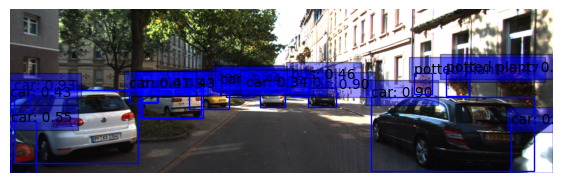

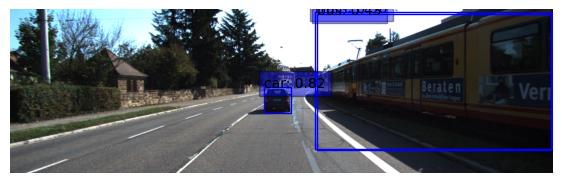

In [50]:
# KITTI 이미지 몇 장을 사전학습 RetinaNet(inference_model)으로 추론해 시각화합니다.
for idx in range(2):
    image, _ = kitti_train[idx]                 # PIL image
    input_image, ratio = prepare_image(image)
    with torch.no_grad():
        detections = inference_model(input_image)[0]

    keep = detections["scores"] > 0.3
    boxes = detections["boxes"][keep] / ratio
    labels = detections["labels"][keep]
    scores = detections["scores"][keep]
    class_names = [COCO_CLASSES[int(l)] for l in labels]

    visualize_detections(image, boxes, class_names, scores)

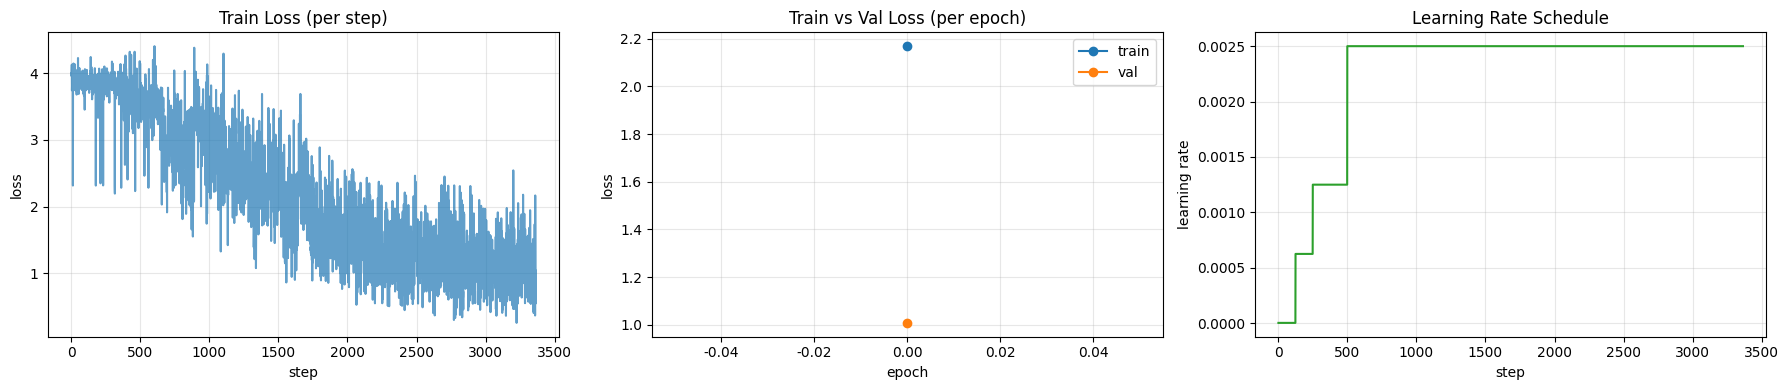

In [41]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1) step별 train loss (세밀한 변화 확인용)
steps, step_losses = zip(*history["step_losses"])
axes[0].plot(steps, step_losses, color="tab:blue", alpha=0.7)
axes[0].set_title("Train Loss (per step)")
axes[0].set_xlabel("step")
axes[0].set_ylabel("loss")
axes[0].grid(True, alpha=0.3)

# 2) epoch별 train vs val loss (과적합 여부 확인용)
epochs_range = range(len(history["epoch_train_loss"]))
axes[1].plot(epochs_range, history["epoch_train_loss"], marker="o", label="train")
axes[1].plot(epochs_range, history["epoch_val_loss"], marker="o", label="val")
axes[1].set_title("Train vs Val Loss (per epoch)")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3) learning rate 스케줄 확인용
lr_steps, lrs = zip(*history["lr"])
axes[2].plot(lr_steps, lrs, color="tab:green")
axes[2].set_title("Learning Rate Schedule")
axes[2].set_xlabel("step")
axes[2].set_ylabel("learning rate")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 학습 결과 해석

### 요약
- **평균 train loss**: 2.1683
- **평균 val loss**: 1.0084
- 1개 epoch(약 3350+ step) 동안 loss가 **4.0 → 0.5 부근까지 꾸준히 감소**했습니다. Focal Loss + Smooth L1로 구성된 RetinaNet 학습이 정상적으로 진행되고 있다는 신호입니다.

### 눈에 띄는 특징

1. **전반적인 하락 추세**: 1 epoch만으로도 모델이 KITTI 데이터의 패턴을 상당히 학습했다고 볼 수 있습니다.
2. **step별 변동(noise)이 큼**: 같은 구간 안에서도 loss가 위아래로 튀는 게 보입니다. 이는 배치마다 등장하는 이미지의 난이도(물체 수, 크기, 클래스 분포)가 달라서 생기는 자연스러운 현상이며 특히 `batch_size`가 작을수록(현재 2로 설정) 이런 변동이 더 크게 나타납니다.
3. **train_loss(2.1683) > val_loss(1.0084)**: 일반적으로는 train loss가 val loss보다 낮은 경우가 많은데, 여기서는 반대입니다. 이는 train_loss가 epoch 전체(step 0~3350)의 평균인 반면에 val_loss는 epoch이 끝난 시점(가장 loss가 낮아진 상태)에서 한 번만 측정되었기 때문입니다.

# 1. 자율주행 시스템 만들기
---

  - 입력으로 이미지 경로를 받습니다.
  - 정지조건에 맞는 경우 "Stop" 아닌 경우 "Go"를 반환합니다.
  - 조건은 다음과 같습니다.
    - 사람이 한 명 이상 있는 경우
    - 차량의 크기(width or height)가 300px이상인 경우

In [42]:
img_path = DATA_PATH + '/stop_1.png'

def self_drive_assist(img_path, size_limit=300):
    # 이미지를 읽어 텐서로 변환
    image = Image.open(img_path).convert("RGB")
    input_tensor = transforms.ToTensor()(image)

    # 앞에서 준비한 inference_model(torchvision 사전학습 RetinaNet, COCO 라벨)로 추론
    inference_model.eval()
    with torch.no_grad():
        detections = inference_model([input_tensor])[0]

    # COCO 클래스 인덱스: person=1, bicycle=2, car=3, motorcycle=4, bus=6, truck=8
    PERSON = {1}
    VEHICLES = {2, 3, 4, 6, 8}
    score_threshold = 0.5

    for box, label, score in zip(detections["boxes"], detections["labels"], detections["scores"]):
        if score < score_threshold:
            continue
        label = int(label)
        x1, y1, x2, y2 = box.tolist()
        w, h = x2 - x1, y2 - y1
        if label in PERSON:
            return "Stop"
        if label in VEHICLES and max(w, h) >= size_limit:
            return "Stop"

    return "Go"

print(self_drive_assist(img_path))

Stop


In [43]:
def self_drive_assist_with_boxes(img_path, size_limit=300, score_threshold=0.5):
    """self_drive_assist와 동일한 판단 로직이지만 시각화를 위해 박스/라벨/점수도 함께 반환합니다."""
    # 이미지를 읽어 텐서로 변환
    image = Image.open(img_path).convert("RGB")
    input_tensor = transforms.ToTensor()(image)

    # 앞에서 준비한 inference_model(torchvision 사전학습 RetinaNet, COCO 라벨)로 추론
    inference_model.eval()
    with torch.no_grad():
        detections = inference_model([input_tensor])[0]

    # COCO 클래스 인덱스: person=1, bicycle=2, car=3, motorcycle=4, bus=6, truck=8
    PERSON = {1}
    VEHICLES = {2, 3, 4, 6, 8}

    keep = detections["scores"] > score_threshold
    boxes = detections["boxes"][keep]
    labels = detections["labels"][keep]
    scores = detections["scores"][keep]

    decision = "Go"
    for box, label, score in zip(boxes, labels, scores):
        label_id = int(label)
        x1, y1, x2, y2 = box.tolist()
        w, h = x2 - x1, y2 - y1
        if label_id in PERSON:
            # 사람이 탐지되면 무조건 정지
            decision = "Stop"
            break
        # 차량의 width 또는 height가 size_limit(기본 300px) 이상이면 정지
        if label_id in VEHICLES and max(w, h) >= size_limit:
            decision = "Stop"
            break

    class_names = [COCO_CLASSES[int(l)] for l in labels]
    return image, boxes, class_names, scores, decision

[stop_1.png] 판단: Stop


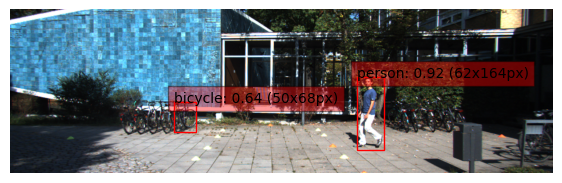

[stop_2.png] 판단: Stop


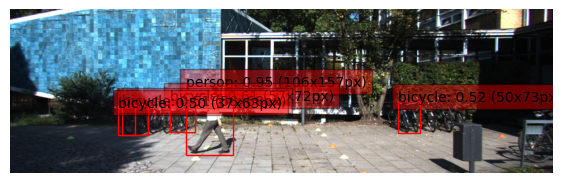

[stop_3.png] 판단: Go


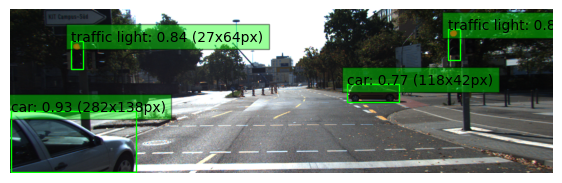

[stop_4.png] 판단: Stop


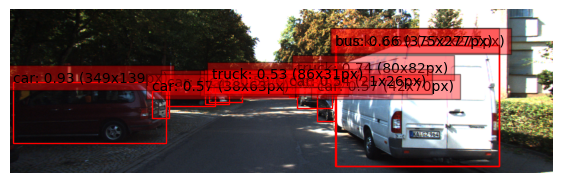

[stop_5.png] 판단: Stop


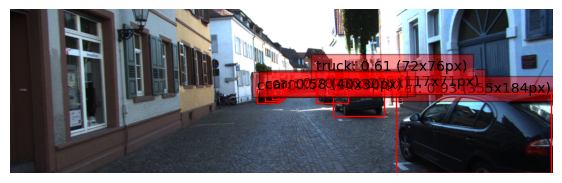

[go_1.png] 판단: Go


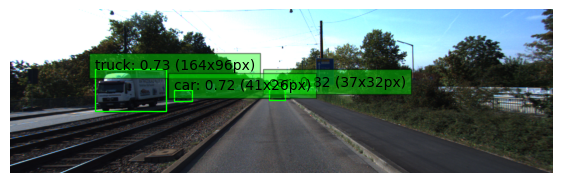

[go_2.png] 판단: Go


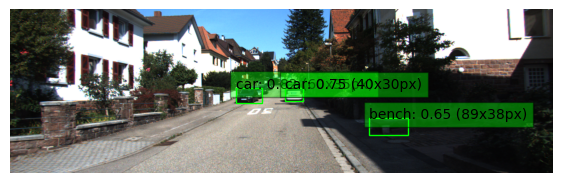

[go_3.png] 판단: Stop


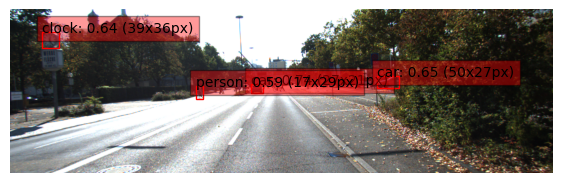

[go_4.png] 판단: Go


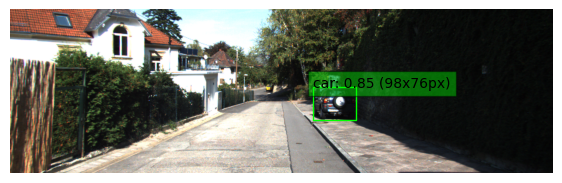

[go_5.png] 판단: Go


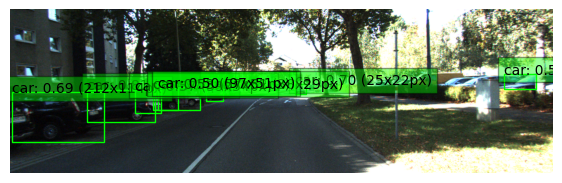

[person.jpg] 판단: Stop


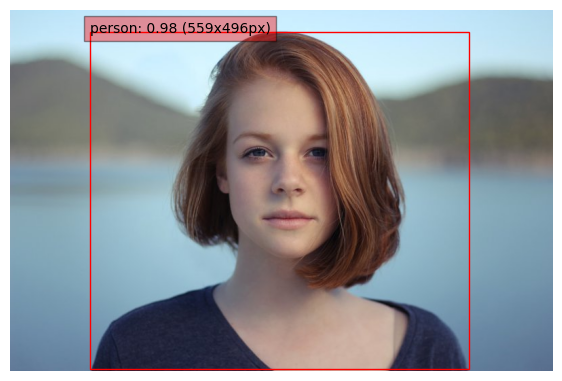

In [51]:
test_files = [
    "stop_1.png", "stop_2.png", "stop_3.png", "stop_4.png", "stop_5.png",
    "go_1.png", "go_2.png", "go_3.png", "go_4.png", "go_5.png", "person.jpg",
]

for file_name in test_files:
    img_path = DATA_PATH + '/' + file_name
    image, boxes, class_names, scores, decision = self_drive_assist_with_boxes(img_path)

    color = [1, 0, 0] if decision == "Stop" else [0, 1, 0]   # Stop=빨강, Go=초록
    print(f"[{file_name}] 판단: {decision}")
    visualize_detections(image, boxes, class_names, scores, color=color, show_size=True)

# 2. 자율주행 시스템 평가하기
---
아래 `test_system()` 를 통해서 위에서 만든 함수를 평가해봅니다. 11장에 대해 Go와 Stop을 맞게 반환하는지 확인하고 100점 만점으로 평가합니다.

In [45]:
def test_system(func):
    work_dir = DATA_PATH
    score = 0
    test_set=[
        ("stop_1.png", "Stop"),
        ("stop_2.png", "Stop"),
        ("stop_3.png", "Stop"),
        ("stop_4.png", "Stop"),
        ("stop_5.png", "Stop"),
        ("go_1.png", "Go"),
        ("go_2.png", "Go"),
        ("go_3.png", "Go"),
        ("go_4.png", "Go"),
        ("go_5.png", "Go"),
        ("person.jpg", "Stop"),
    ]

    per_item_score = 100 / len(test_set)   # 항목 개수에 맞춰 배점 자동 조정

    for image_file, answer in test_set:
        image_path = work_dir + '/' + image_file
        try:
            pred = func(image_path)
        except Exception as e:
            print(f"[{image_file}] 예측 중 오류 발생: {e}")
            continue
        correct = (pred == answer)
        if correct:
            score += per_item_score
        print(f"[{image_file}] 정답: {answer}, 예측: {pred} -> {'O' if correct else 'X'}")

    print(f"{score:.1f}점입니다.")

test_system(self_drive_assist)

[stop_1.png] 정답: Stop, 예측: Stop -> O
[stop_2.png] 정답: Stop, 예측: Stop -> O
[stop_3.png] 정답: Stop, 예측: Go -> X
[stop_4.png] 정답: Stop, 예측: Stop -> O
[stop_5.png] 정답: Stop, 예측: Stop -> O
[go_1.png] 정답: Go, 예측: Go -> O
[go_2.png] 정답: Go, 예측: Go -> O
[go_3.png] 정답: Go, 예측: Stop -> X
[go_4.png] 정답: Go, 예측: Go -> O
[go_5.png] 정답: Go, 예측: Go -> O
[person.jpg] 정답: Stop, 예측: Stop -> O
81.8점입니다.


# 결과 분석

5가지의 stop.png와 5가지의 go.png 중 stop.png 1장, go.png 1장 총 두 장을 잘못 판단하였으며 판단 결과는 아래와 같이 나타났다.

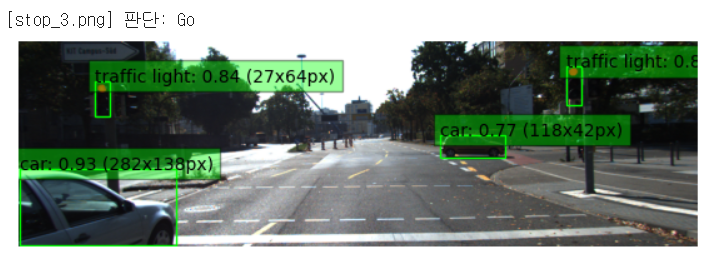

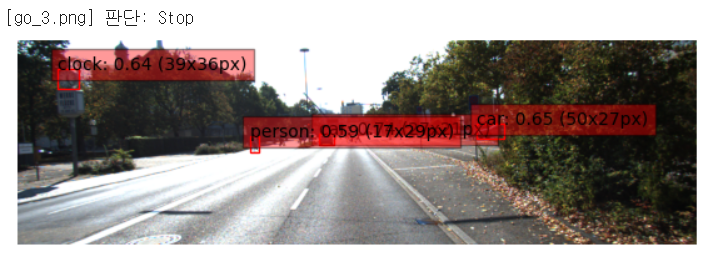

첫 번째로 stop_3.png 사진을 go로 판단한 것은 사람이 없고 차가 300px을 넘지 않았기 때문이다.

두 번재로 go_3.png 사진을 stop으로 판단한 것은 사람으로 판단한 객체가 있기 때문이며 이를 위해 아래 셀에서 원본 사진을 출력 해보면 실제로 사람이 있음을 알 수 있다.

이를 토대로 모델의 성능상의 문제는 없지만 테스트를 위한 사진에 오류가 있음을 알 수 있다.

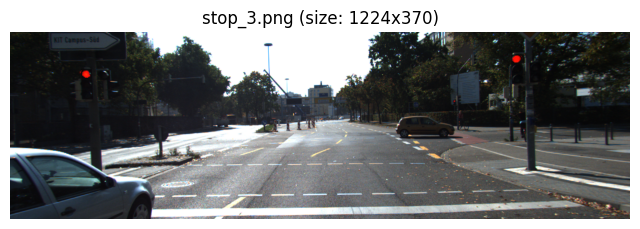

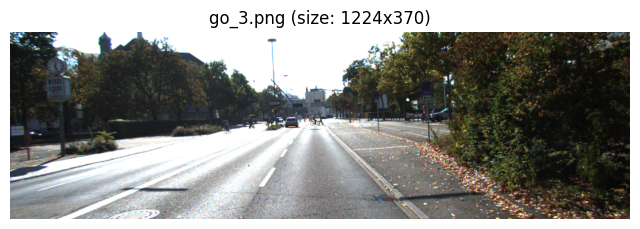

In [46]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(DATA_PATH + '/stop_3.png')
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis('off')
plt.title(f"stop_3.png (size: {image.size[0]}x{image.size[1]})")
plt.show()

image = Image.open(DATA_PATH + '/go_3.png')
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis('off')
plt.title(f"go_3.png (size: {image.size[0]}x{image.size[1]})")
plt.show()